# Spam Classification using Logistic Regression

Author: Saket Kumar Sinha    
Roll number: 2410110289

## Objective
The goal of this project is to build a machine learning model that classifies SMS messages as spam or ham (not spam) using logistic regression and natural language processing techniques.

---

## Dataset
- Source: UCI SMS Spam Collection Dataset
- Total messages: 5,574
- Labels:
  - ham → normal messages
  - spam → unwanted messages

## Step 1: Data Loading and Exploration

In this step, we:
- Load the dataset into a Pandas DataFrame
- Assign proper column names
- Perform basic exploratory data analysis (EDA)

### Tasks:
- Check dataset shape
- View sample data
- Analyze class distribution
- Compute message lengths

In [7]:
import pandas as pd

df = pd.read_csv("/home/saket-ubuntu/Spam-Classifier/Dataset/sms+spam+collection/SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

df.head(5)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
print("The shape of the dataframe is:", df.shape)
print("The info of the dataframe is:", df.info)
print("The description of the dataframe is:", df.describe())

The shape of the dataframe is: (5572, 2)
The info of the dataframe is: <bound method DataFrame.info of      label                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>
The description of the dataframe is:        label                 message
count   5572                    5572
unique     2    

### Observations

- The dataset contains two columns:
  - label → spam/ham
  - message → text content
- Messages vary in length
- Both spam and ham messages are present

In [11]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

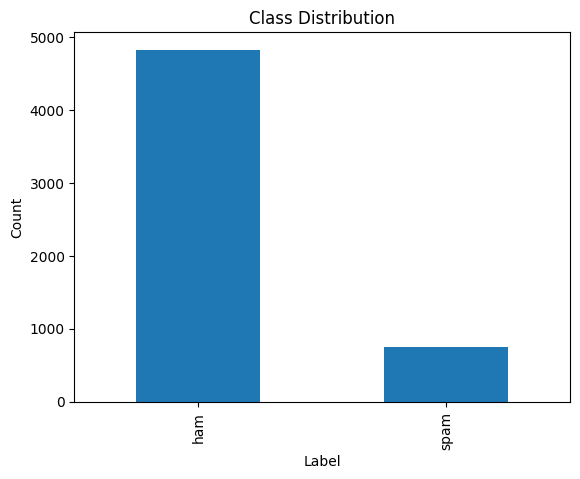

In [13]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Class Distribution Analysis

- The dataset is imbalanced
- There are significantly more ham messages than spam messages

### Question: Is the dataset balanced?

No, the dataset is not balanced. Ham messages dominate the dataset.

In [14]:
df['length'] = df['message'].apply(len)

df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


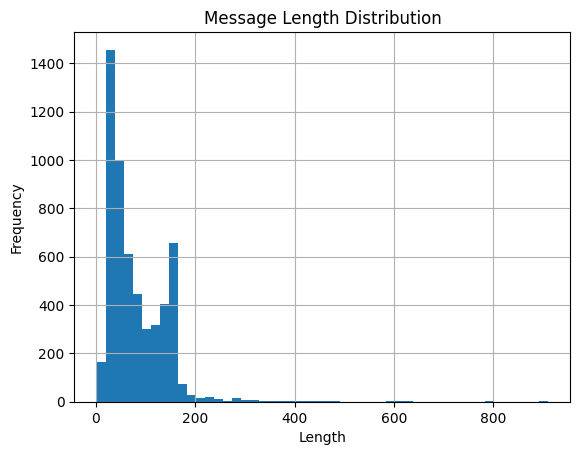

In [15]:
df['length'].hist(bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Message Length Distribution

The histogram shows the distribution of message lengths across the dataset.

Observations:
- Most messages are relatively short (below 200 characters)
- A small number of messages are significantly longer, forming a long tail
- This indicates a right-skewed distribution

Conclusion:
Most SMS messages are short, but spam messages tend to include longer content such as offers or detailed instructions.

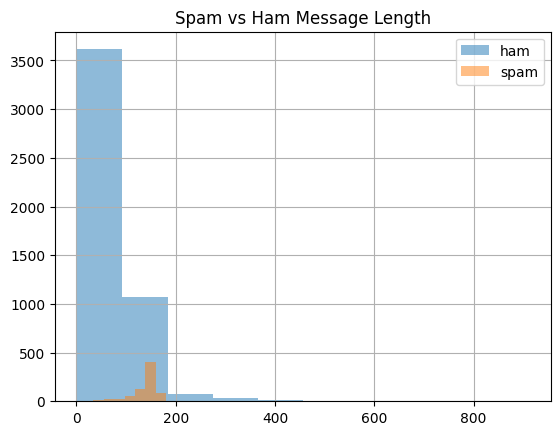

In [16]:
df[df['label']=='ham']['length'].hist(alpha=0.5, label='ham')
df[df['label']=='spam']['length'].hist(alpha=0.5, label='spam')
plt.legend()
plt.title("Spam vs Ham Message Length")
plt.show()

### Spam vs Ham Message Length

This plot compares the distribution of message lengths for spam and ham messages.

Observations:
- Spam messages are generally longer than ham messages
- Ham messages are concentrated in shorter length ranges
- Spam messages show a wider spread

Conclusion:
Message length can be a useful feature for distinguishing between spam and ham messages.

In [18]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df.groupby('label')['word_count'].mean()

label
ham     14.310259
spam    23.911647
Name: word_count, dtype: float64

### Word Count Analysis

The average word count for each class is computed.

Results:
- Ham messages: approximately 14 words on average
- Spam messages: approximately 24 words on average

Conclusion:
Spam messages tend to contain more words than ham messages, often due to promotional or descriptive content.

In [19]:
from collections import Counter

all_words = " ".join(df['message']).split()
Counter(all_words).most_common(20)

[('to', 2145),
 ('you', 1626),
 ('I', 1469),
 ('a', 1337),
 ('the', 1207),
 ('and', 858),
 ('in', 800),
 ('is', 788),
 ('i', 748),
 ('u', 698),
 ('for', 650),
 ('my', 630),
 ('of', 592),
 ('me', 561),
 ('your', 561),
 ('on', 488),
 ('have', 477),
 ('2', 457),
 ('that', 422),
 ('it', 397)]

In [20]:
spam_words = " ".join(df[df['label']=='spam']['message']).split()
Counter(spam_words).most_common(20)

[('to', 607),
 ('a', 360),
 ('your', 187),
 ('call', 185),
 ('or', 185),
 ('the', 178),
 ('2', 169),
 ('for', 169),
 ('you', 164),
 ('is', 143),
 ('Call', 136),
 ('on', 136),
 ('have', 128),
 ('and', 119),
 ('from', 116),
 ('ur', 107),
 ('with', 101),
 ('&', 98),
 ('4', 93),
 ('of', 93)]

In [21]:
ham_words = " ".join(df[df['label']=='ham']['message']).split()
Counter(ham_words).most_common(20)

[('to', 1538),
 ('you', 1462),
 ('I', 1439),
 ('the', 1029),
 ('a', 977),
 ('i', 742),
 ('and', 739),
 ('in', 736),
 ('u', 651),
 ('is', 645),
 ('my', 621),
 ('me', 541),
 ('of', 499),
 ('for', 481),
 ('that', 399),
 ('it', 376),
 ('your', 374),
 ('on', 352),
 ('have', 349),
 ('at', 334)]

In [24]:
df.isnull().sum()

label         0
message       0
length        0
word_count    0
dtype: int64

### Missing Values Analysis

The dataset was checked for missing values.

Observation:
- No missing values were found in any column

Conclusion:
The dataset is clean and does not require handling of missing data.

In [25]:
df.duplicated().sum()

np.int64(403)

In [26]:
df = df.drop_duplicates()

### Duplicate Messages

The dataset contains duplicate messages.

Observation:
- 403 duplicate entries were found

Action Taken:
- Duplicate messages were removed to avoid bias in the model

Conclusion:
Removing duplicates ensures that the model does not learn redundant patterns.

In [27]:
df['has_number'] = df['message'].apply(lambda x: any(char.isdigit() for char in x))

df.groupby('label')['has_number'].mean()

label
ham     0.158105
spam    0.940276
Name: has_number, dtype: float64

### Presence of Numbers in Messages

A feature was created to check whether a message contains numerical characters.

Results:
- Spam messages have a much higher proportion of numbers
- Ham messages rarely contain numbers

Conclusion:
Numbers are a strong indicator of spam messages (e.g., offers, phone numbers, codes).

In [28]:
df['upper_case'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))

df.groupby('label')['upper_case'].mean()

label
ham      3.982064
spam    15.267994
Name: upper_case, dtype: float64

### Uppercase Character Analysis

The number of uppercase characters was analyzed.

Results:
- Spam messages contain significantly more uppercase letters
- Ham messages have fewer uppercase characters

Conclusion:
Spam messages often use uppercase text for emphasis and attention. 

In [29]:
df[['length', 'word_count', 'upper_case']].corr()

,length,word_count,upper_case
length,1.000000,0.973858,0.358952
word_count,0.973858,1.000000,0.322841
upper_case,0.358952,0.322841,1.000000


### Correlation Analysis

Correlation between numerical features was computed.

Observations:
- Message length and word count are highly correlated
- Uppercase usage has moderate correlation with length and word count

Conclusion:
Length and word count capture similar information, while uppercase usage provides additional signal.

### Differences Between Spam and Ham Messages

From the exploratory data analysis, several key differences between spam and ham messages were observed:

1. Message Length  
Spam messages are generally longer than ham messages. They often include detailed promotional content, while ham messages are shorter and more conversational.

2. Word Count  
Spam messages contain more words on average compared to ham messages, reflecting their descriptive and advertising nature.

3. Use of Numbers  
Spam messages frequently include numbers (e.g., phone numbers, prize amounts, codes), whereas ham messages rarely contain numerical information.

4. Use of Uppercase Letters  
Spam messages tend to use more uppercase characters to grab attention (e.g., "WIN", "FREE"), while ham messages use normal sentence casing.

5. Vocabulary  
Spam messages contain promotional and action-oriented words such as "free", "win", "offer", and "call".  
Ham messages use more natural, conversational words like "ok", "go", "home", and "call" (in a normal context).

6. Structure and Tone  
Spam messages are often structured to persuade or create urgency, while ham messages reflect casual, everyday communication.

### Conclusion  
Spam messages are typically longer, more structured, and contain promotional language, numbers, and uppercase emphasis.  
Ham messages are shorter, more informal, and resemble natural human conversation.

In [30]:
df.to_csv("/home/saket-ubuntu/Spam-Classifier/Dataset/cleaned_data.csv", index=False)